In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Loading Data
file_path = '/kaggle/input/datasets/vagifa/ethereum-frauddetection-dataset/transaction_dataset.csv' 
df = pd.read_csv(file_path)
print("Loading success!")

# 2. File Info
print(f"\nFile Info (rows, columns): {df.shape}")

# 3. Count Flags
# '1' means fraud, '0' means normal
if 'FLAG' in df.columns:
    print("\n----- Flag Distribution -----")
    print(df['FLAG'].value_counts())
    
    print("\n----- Fraud Ratio -----")
    print(df['FLAG'].value_counts(normalize=True) * 100) 
else:
    print("\nUnable to find 'FLAG' columns, please check the dataset.")

Loading success!

File Info (rows, columns): (9841, 51)

----- Flag Distribution -----
FLAG
0    7662
1    2179
Name: count, dtype: int64

----- Fraud Ratio -----
FLAG
0    77.857941
1    22.142059
Name: proportion, dtype: float64


In [23]:
# Data Preprocessing & Feature Enhancement

print("Implementing Enhanced Features...")

# A. Behavioral Features
# Transaction Frequency (TPS Proxy) - Relies on 'Time Diff' which is leakage
df['txn_frequency'] = (df['Sent tnx'] + df['Received Tnx']) / (df['Time Diff between first and last (Mins)'] + 1e-6)

# Sent/Received Ratio
df['ether_sent_rec_ratio'] = df['total Ether sent'] / (df['total ether received'] + 1e-6)

# B. Network Topology Proxy
# Unique Address Ratio
df['unique_sent_ratio'] = df['Unique Sent To Addresses'] / (df['Sent tnx'] + 1e-6)
df['unique_rec_ratio'] = df['Unique Received From Addresses'] / (df['Received Tnx'] + 1e-6)

# C. Statistical Distribution
# Max-to-Mean Ratio
df['rec_max_mean_ratio'] = df['max value received '] / (df['avg val received'] + 1e-6)
df['sent_max_mean_ratio'] = df['max val sent'] / (df['avg val sent'] + 1e-6)

# D. Log Transformation
value_cols = ['total Ether sent', 'total ether received', 'max value received ', 
              'avg val received', 'max val sent', 'avg val sent', 
              'total transactions (including tnx to create contract']
for col in value_cols:
    if col in df.columns:
        df[f'log_{col.strip()}'] = np.log1p(df[col])

# E. Data Cleaning & Leakage Removal
print("Cleaning data and removing leakage features...")

to_drop = [
    'Index', 'Address', 'Unnamed: 0', 
    # 'Time Diff between first and last (Mins)', 
    # 'total ether balance', 
    # 'ERC20 most sent token type', 
    # 'ERC20_most_rec_token_type'
]
df_cleaned = df.drop(columns=[c for c in to_drop if c in df.columns])

constant_cols = [col for col in df_cleaned.columns if df_cleaned[col].nunique() <= 1]
df_cleaned = df_cleaned.drop(columns=constant_cols)

for col in df_cleaned.columns:
    if col != 'FLAG':
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')

df_cleaned = df_cleaned.fillna(df_cleaned.median(numeric_only=True))

print(f"Data cleaning and enhancement complete! Features: {df_cleaned.shape[1]}")

Implementing Enhanced Features...
Cleaning data and removing leakage features...
Data cleaning and enhancement complete! Features: 54


In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
# 3. Modeling Pipeline
X = df_cleaned.drop('FLAG', axis=1)
y = df_cleaned['FLAG']

# Implement an ordered split (shuffle=False) as a proxy for Out-of-Time (OOT) validation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# X_train_res, y_train_res = X_train_scaled, y_train
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print(f"Training samples after SMOTE: {len(X_train_res)}")

Training samples after SMOTE: 12242



--- Random Forest ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1541
           1       0.96      0.96      0.96       428

    accuracy                           0.98      1969
   macro avg       0.97      0.97      0.97      1969
weighted avg       0.98      0.98      0.98      1969



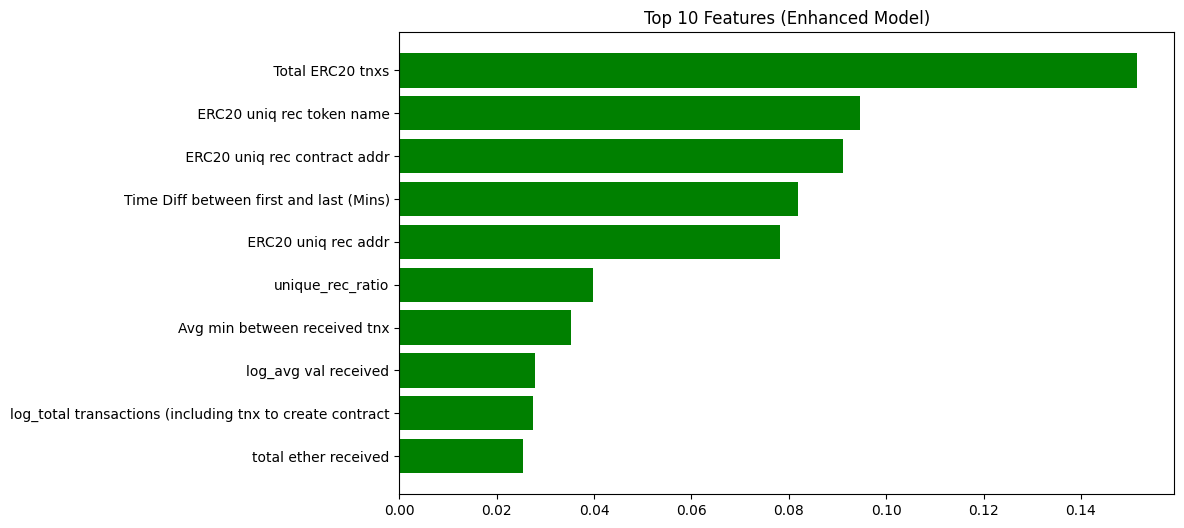

In [25]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
# 4. Training and Evaluation 
# Random Forest
print("\n--- Random Forest ---")
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))

# 5. Feature Importance
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'].head(10), feature_importance_df['Importance'].head(10), color='green')
plt.gca().invert_yaxis()
plt.title('Top 10 Features (Enhanced Model)')
plt.show()

In [26]:
# 4. Model Benchmarking
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
# KNN
print("\n--- KNN ---")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_res, y_train_res)
print(classification_report(y_test, knn.predict(X_test_scaled)))

# XGBoost
print("\n--- XGBoost ---")
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)
print(classification_report(y_test, xgb.predict(X_test_scaled)))


--- KNN ---
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1541
           1       0.80      0.93      0.86       428

    accuracy                           0.94      1969
   macro avg       0.89      0.93      0.91      1969
weighted avg       0.94      0.94      0.94      1969


--- XGBoost ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1541
           1       0.96      0.97      0.96       428

    accuracy                           0.98      1969
   macro avg       0.97      0.98      0.98      1969
weighted avg       0.98      0.98      0.98      1969

